# Stage 3 — Evaluation: 4-Value Neural Baker Analysis

Analyses the performance and accuracy of the Stage 3 Neural LOD system which predicts **four independent thresholds**.

**Goals**:
1. Compare 4 predicted thresholds against geometric Oracle thresholds.
2. Evaluate runtime performance (CPU/GPU/FPS) vs Stage 2 or Baselines.
3. Check for monotonic enforcement integrity ($T0 > T1 > T2 > T3$).

In [26]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_style('darkgrid')
print('Libraries loaded OK')

Libraries loaded OK


In [27]:
BASE_DIR = Path('../..').resolve()
EVAL_DIR = BASE_DIR / 'data' / 'Baker_Eval_3'
PLOTS_DIR = BASE_DIR / 'plots' / 'Stage_3' / 'Eval'
OBJECTS_FILE = BASE_DIR / 'data' / 'Baker_2' / 'lod_objects.csv'

PLOTS_DIR.mkdir(parents=True, exist_ok=True)

RUN_COLORS = {
    'neural_4thresh':     '#2196F3',
    'neural_baker_4val':  '#2196F3',
    'fixed_default':      '#4CAF50',
    'fixed_aggressive':   '#FF9800',
}
DEFAULT_COLOR = '#9C27B0'

FRAME_BUDGET_MS = 16.67 # 60 FPS

## 1. Load Stage 3 Eval Data

In [28]:
csv_files = list(EVAL_DIR.glob('inference_eval_*.csv'))
print(f'Found {len(csv_files)} eval CSVs in {EVAL_DIR}')

dfs = []
for f in csv_files:
    df = pd.read_csv(f)
    df['source_file'] = f.name
    dfs.append(df)

if not dfs:
    raise FileNotFoundError("No evaluation files found.")

data = pd.concat(dfs, ignore_index=True)

# Ensure numeric columns for 4 thresholds
threshold_cols = ['predicted_t0', 'predicted_t1', 'predicted_t2', 'predicted_t3']
numeric_cols = ['cpu_ms', 'gpu_ms', 'fps', 'inference_duration_ms'] + threshold_cols
for col in numeric_cols:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce')

print(f'Loaded {len(data)} frames across {data[ "run_label" ].nunique()} runs.')
data.head()

Found 1 eval CSVs in C:\Users\Gica\neural-lod\ml_pipeline\data\Baker_Eval_3
Loaded 4246 frames across 1 runs.


,run_label,frame,cpu_ms,gpu_ms,fps,inference_duration_ms,predicted_t0,predicted_t1,predicted_t2,predicted_t3,predicted_threshold_mean,lod_bias_applied,threshold_changed,cam_pos_x,cam_pos_y,cam_pos_z,cam_rot_x,cam_rot_y,cam_rot_z,source_file
0,neural_4thresh,0,11.3101,0.0000,54.9943,0.5179,0.1084,0.021833,0.002327,0.0,0.03314,2.0,0,35.6101,2.4967,33.3750,6.66,-178.8,0.0,inference_eval_neural_4thresh_20260402_165312.csv
1,neural_4thresh,1,17.1718,8.0865,17.1498,0.5179,0.1084,0.021833,0.002327,0.0,0.03314,2.0,0,35.6049,2.5214,33.0770,6.66,-178.8,0.0,inference_eval_neural_4thresh_20260402_165312.csv
2,neural_4thresh,2,7.3382,0.0000,85.3774,0.5179,0.1084,0.021833,0.002327,0.0,0.03314,2.0,0,35.6030,2.5291,32.9773,6.66,-178.8,0.0,inference_eval_neural_4thresh_20260402_165312.csv
3,neural_4thresh,3,55.6253,9.7147,38.9622,0.5179,0.1084,0.021833,0.002327,0.0,0.03314,2.0,0,35.6011,2.5358,32.8775,6.66,-178.8,0.0,inference_eval_neural_4thresh_20260402_165312.csv
4,neural_4thresh,4,19.6320,8.7665,73.3730,0.5179,0.1084,0.021833,0.002327,0.0,0.03314,2.0,0,35.5991,2.5426,32.7778,6.66,-178.8,0.0,inference_eval_neural_4thresh_20260402_165312.csv


## 2. Oracle Generation (Geometric Ground Truth)
Stage 3 predicts transition heights. We derive the Oracle heights based on the `optimal_lod` logic used during training.

In [29]:
df_objects = pd.read_csv(OBJECTS_FILE)
qual_map = {0: 1.0, 1: 0.8, 2: 0.6, 3: 0.4}

# Parse base thresholds from objects.csv
all_thresholds = []
for t_str in df_objects['thresholds']:
    vals = [float(v) for v in str(t_str).split(';') if v.strip()]
    if len(vals) < 4: vals += [0.001] * (4 - len(vals))
    all_thresholds.append(vals[:4])
base_vector = np.mean(all_thresholds, axis=0)

def calculate_oracle_vector(optimal_lod):
    mult = qual_map.get(int(optimal_lod), 0.4)
    return base_vector * mult

# Generate ground truth for eval data if optimal_lod is present
if 'optimal_lod' in data.columns:
    oracles = np.array([calculate_oracle_vector(lod) for lod in data['optimal_lod']])
    for i in range(4):
        data[f'oracle_threshold_{i}'] = oracles[:, i]
    print("✓ Oracle thresholds generated.")
else:
    print("ℹ Oracle comparison skipped: Evaluation data does not contain 'optimal_lod' labels.")
    print("  (This is normal if you are evaluating inference in a live scene without an active Oracle script)")

ℹ Oracle comparison skipped: Evaluation data does not contain 'optimal_lod' labels.
  (This is normal if you are evaluating inference in a live scene without an active Oracle script)


## 3. Summary Statistics

In [30]:
summary = data.groupby('run_label').agg({
    'cpu_ms': ['mean', 'std', lambda x: np.percentile(x, 95)],
    'gpu_ms': ['mean', 'std'],
    'fps': ['mean'],
    'inference_duration_ms': ['mean']
})
summary.columns = ['cpu_mean', 'cpu_std', 'cpu_p95', 'gpu_mean', 'gpu_std', 'fps_mean', 'inference_mean']
print("=== Performance Summary ===")
display(summary)

=== Performance Summary ===


,cpu_mean,cpu_std,cpu_p95,gpu_mean,gpu_std,fps_mean,inference_mean
run_label,,,,,,,
neural_4thresh,16.722827,2.260772,17.062175,5.357473,1.013857,60.456843,0.139218


## 4. Threshold Accuracy Analysis

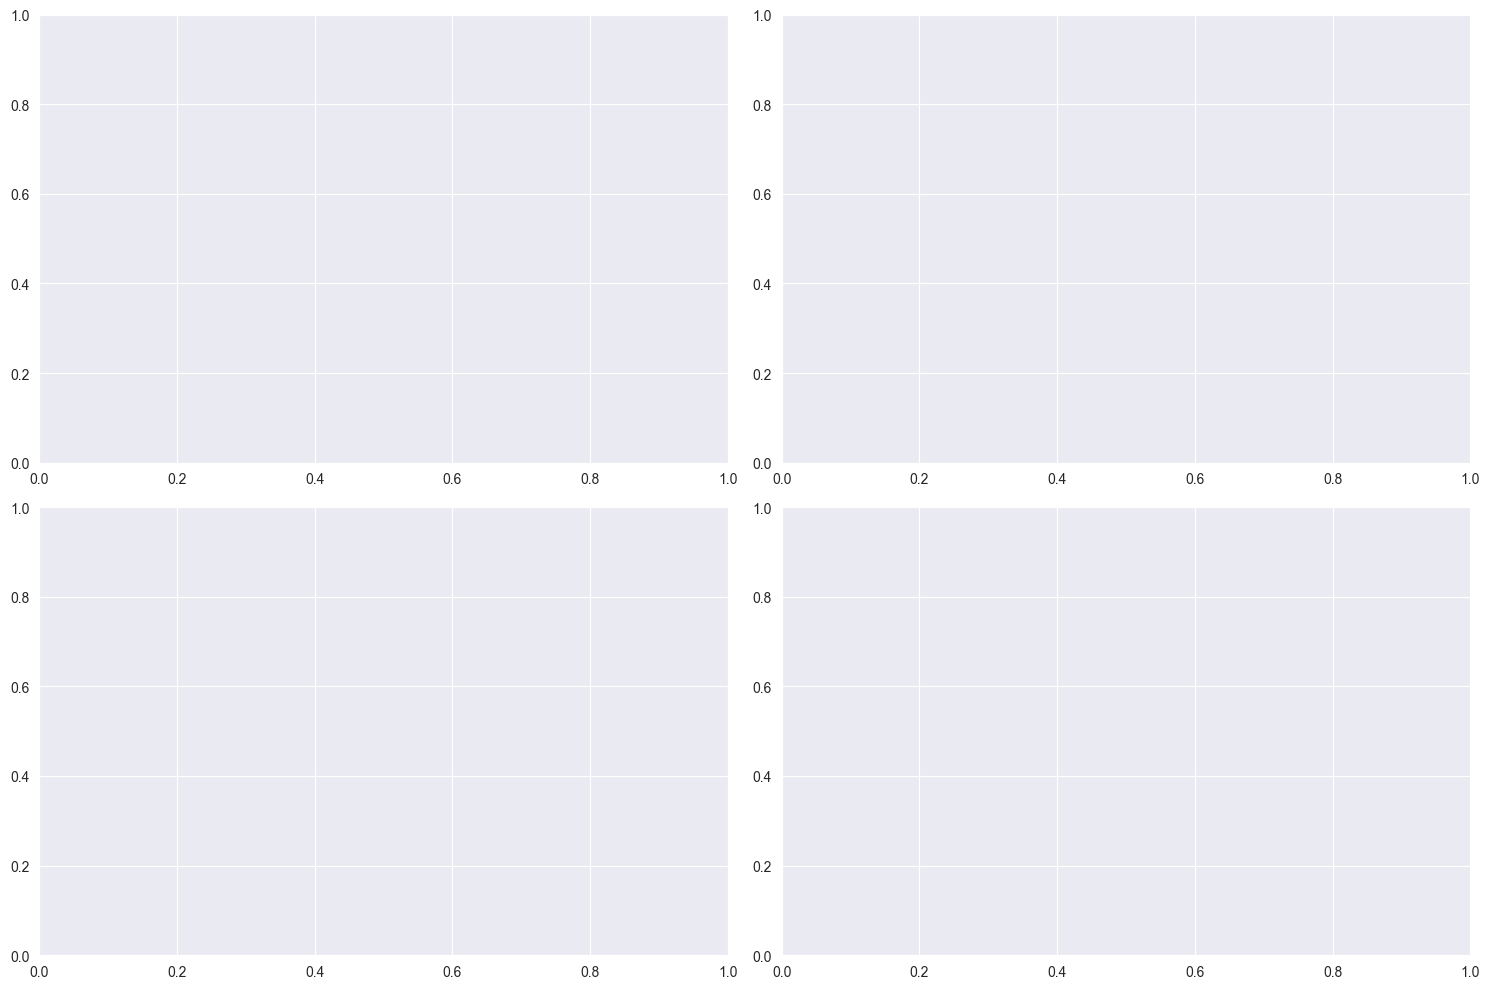

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i in range(4):
    if f'oracle_threshold_{i}' not in data.columns:
        continue
    ax = axes[i]
    sns.scatterplot(data=data, x=f'oracle_threshold_{i}', y=f'predicted_t{i}', 
                    alpha=0.3, ax=ax, color=RUN_COLORS.get('neural_4thresh', DEFAULT_COLOR))
    ax.plot([0, data[f'oracle_threshold_{i}'].max()], [0, data[f'oracle_threshold_{i}'].max()], 'r--')
    ax.set_title(f'Threshold T{i} Accuracy')
    ax.set_xlabel('Oracle Threshold')
    ax.set_ylabel('Predicted Threshold')
    
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'threshold_accuracy_scatter.png')
plt.show()

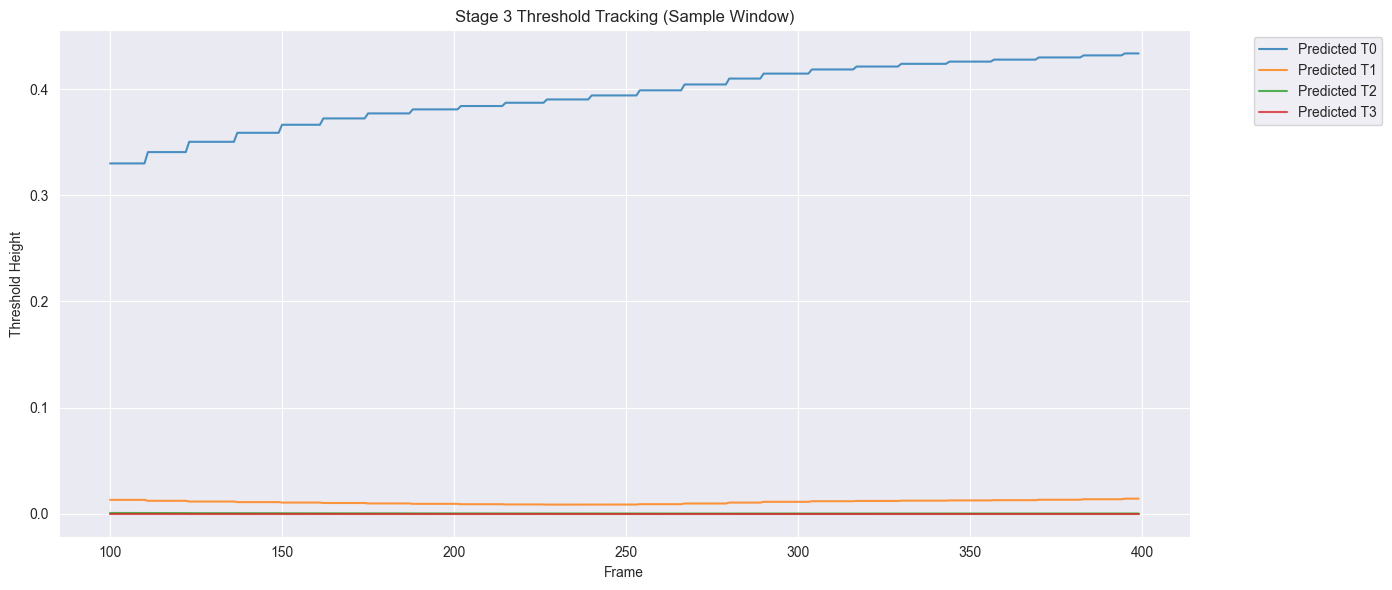

In [32]:
# Plotting a window of time for all 4 thresholds
subset = data.iloc[100:400] # Take a slice of frames
plt.figure(figsize=(14, 6))
for i in range(4):
    plt.plot(subset['frame'], subset[f'predicted_t{i}'], label=f'Predicted T{i}', alpha=0.8)
    if f'oracle_threshold_{i}' in data.columns:
        plt.plot(subset['frame'], subset[f'oracle_threshold_{i}'], label=f'Oracle T{i}', linestyle=':', alpha=0.5)

plt.title('Stage 3 Threshold Tracking (Sample Window)')
plt.xlabel('Frame')
plt.ylabel('Threshold Height')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'threshold_tracking_sample.png')
plt.show()

## 5. Frame Time Comparison

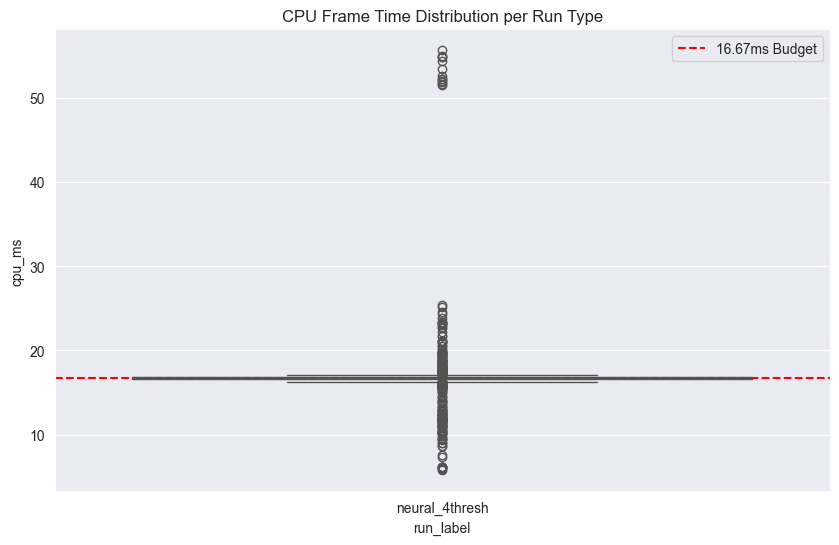

In [33]:
plt.figure(figsize=(10, 6))
current_palette = {label: RUN_COLORS.get(label, DEFAULT_COLOR) for label in data['run_label'].unique()}
sns.boxplot(data=data, x='run_label', y='cpu_ms', palette=current_palette)
plt.axhline(FRAME_BUDGET_MS, color='red', linestyle='--', label=f'{FRAME_BUDGET_MS}ms Budget')
plt.title('CPU Frame Time Distribution per Run Type')
plt.savefig(PLOTS_DIR / 'cpu_comparison.png')
plt.legend()
plt.show()

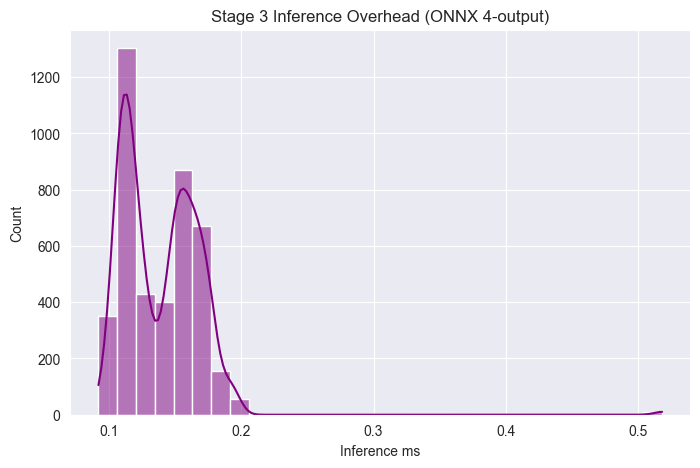

In [34]:
neural_runs = data[data['run_label'].str.contains('neural', case=False)]
if not neural_runs.empty:
    plt.figure(figsize=(8, 5))
    sns.histplot(neural_runs['inference_duration_ms'], bins=30, kde=True, color='purple')
    plt.title('Stage 3 Inference Overhead (ONNX 4-output)')
    plt.xlabel('Inference ms')
    plt.savefig(PLOTS_DIR / 'inference_overhead_dist.png')
    plt.show()